# D599 Task 2 

Univariate Analysis

First few rows of the dataset:
    age     sex     bmi  children smoker     region      charges Level  score
0  19.0  female  27.900       0.0    yes  southwest    16884.924     B   72.0
1  18.0    male  33.770       1.0     no  southeast    1725.5523     C   69.0
2  28.0    male  33.000       3.0     no  southeast     4449.462     B   90.0
3  33.0    male  22.705       0.0     no  northwest  21984.47061     A   47.0
4  32.0    male  28.880       0.0     no  northwest    3866.8552     C   76.0


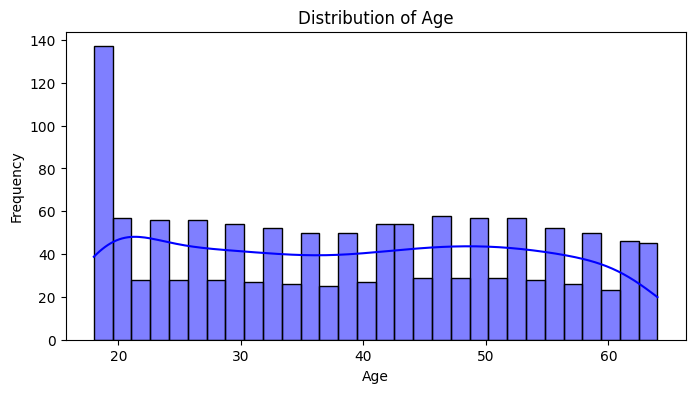

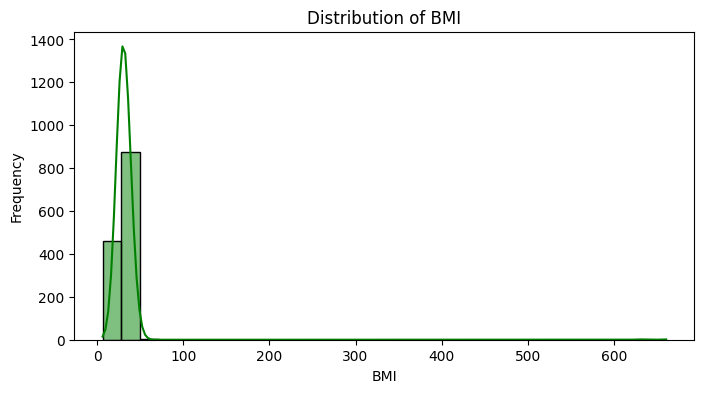

C:\Users\Warren Buenarte\AppData\Local\Temp\ipykernel_16096\1033655092.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', palette='Set2')


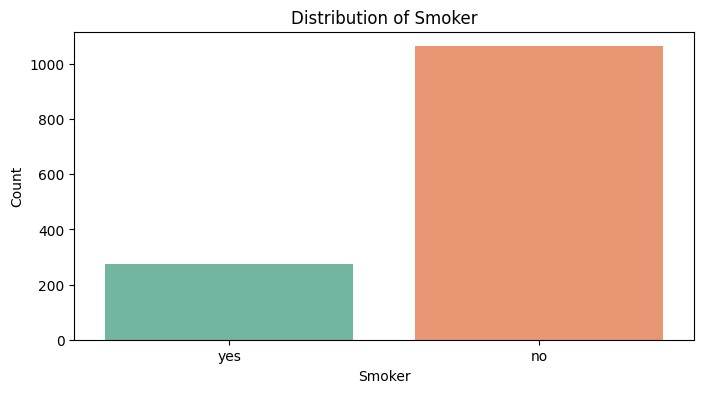

C:\Users\Warren Buenarte\AppData\Local\Temp\ipykernel_16096\1033655092.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', palette='Set3')


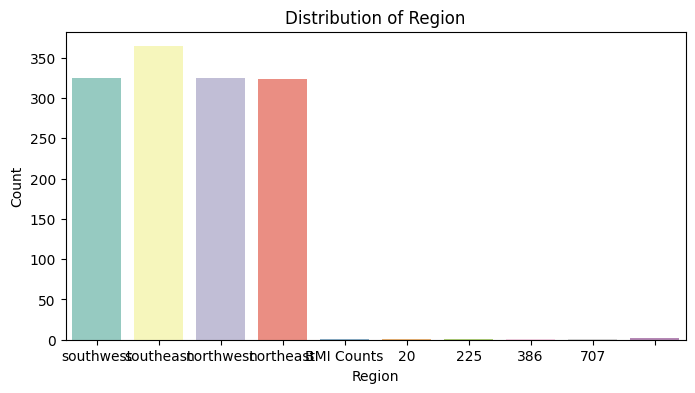

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("Health Insurance Dataset.xlsx", engine='openpyxl')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# 1. Univariate analysis for 'age' (Continuous Variable)
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], kde=True, bins=30, color='blue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 2. Univariate analysis for 'bmi' (Continuous Variable)
plt.figure(figsize=(8, 4))
sns.histplot(df['bmi'], kde=True, bins=30, color='green')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

# 3. Univariate analysis for 'smoker' (Categorical Variable)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='smoker', palette='Set2')
plt.title("Distribution of Smoker")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

# 4. Univariate analysis for 'region' (Categorical Variable)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='region', palette='Set3')
plt.title("Distribution of Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

First few rows of the dataset:
    age     sex     bmi  children smoker     region      charges Level  score
0  19.0  female  27.900       0.0    yes  southwest    16884.924     B   72.0
1  18.0    male  33.770       1.0     no  southeast    1725.5523     C   69.0
2  28.0    male  33.000       3.0     no  southeast     4449.462     B   90.0
3  33.0    male  22.705       0.0     no  northwest  21984.47061     A   47.0
4  32.0    male  28.880       0.0     no  northwest    3866.8552     C   76.0


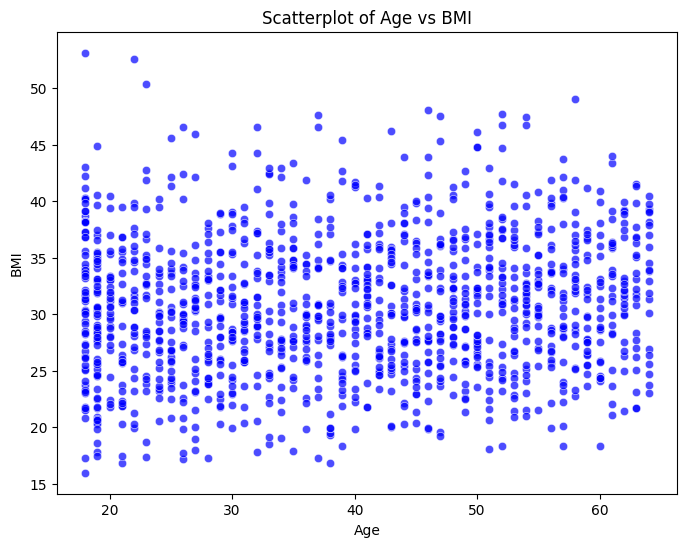


Contingency Table for Smoker vs Region:
region  northeast  northwest  southeast  southwest
smoker                                            
no            257        267        273        267
yes            67         58         91         58


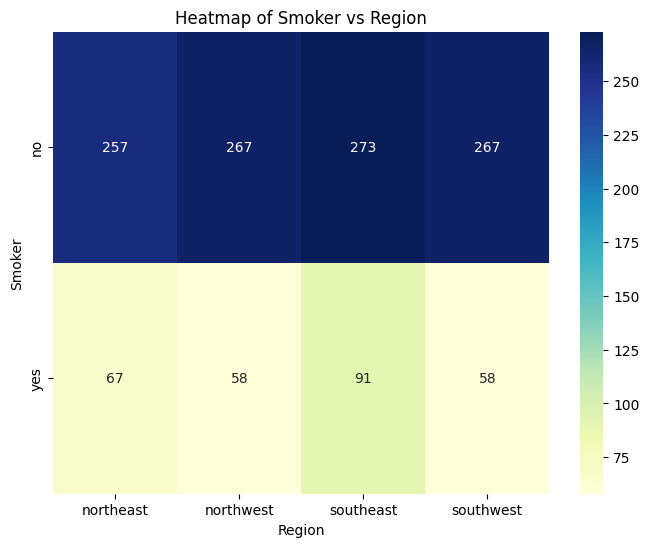

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("Health Insurance Dataset.xlsx", engine='openpyxl')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# 1. Bivariate analysis for 'age' vs 'bmi' (Continuous vs Continuous)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='bmi', color='blue', alpha=0.7)
plt.title("Scatterplot of Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

# 2. Bivariate analysis for 'smoker' vs 'region' (Categorical vs Categorical)
contingency_table = pd.crosstab(df['smoker'], df['region'])
print("\nContingency Table for Smoker vs Region:")
print(contingency_table)

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap of Smoker vs Region")
plt.xlabel("Region")
plt.ylabel("Smoker")
plt.show()

# Parametic Statistical Testing

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Load the dataset
df = pd.read_excel("Health Insurance Dataset.xlsx", engine='openpyxl')

# Debugging: Check unique values in 'smoker'
print("Unique values in 'smoker':", df['smoker'].unique())

# Standardize the 'smoker' column
df['smoker'] = df['smoker'].str.strip().str.lower()

# Check for missing values
print("Missing values in 'smoker':", df['smoker'].isnull().sum())
print("Missing values in 'charges':", df['charges'].isnull().sum())

df['charges'] = pd.to_numeric(df['charges'], errors='coerce')
print("Missing values in 'charges':", df['charges'].isnull().sum())
df = df.dropna(subset=['charges'])  # Drop rows with missing charges
# Filter valid rows
df = df[df['smoker'].isin(['yes', 'no'])]\

# Separate the charges for smokers and non-smokers
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']

# Perform an independent samples t-test
t_stat, p_value = ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)  # Use Welch's t-test if variances are unequal

# Output the results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

Unique values in 'smoker': ['yes' 'no' nan]
Missing values in 'smoker': 10
Missing values in 'charges': 3
Missing values in 'charges': 0
T-Statistic: 32.751887766341824
P-Value: 5.88946444671698e-103


# Non-parametric Statistic Analysis

In [24]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Load the dataset
df = pd.read_excel("Health Insurance Dataset.xlsx", engine='openpyxl')

# Standardize the 'smoker' column
df['smoker'] = df['smoker'].str.strip().str.lower()

# Check for missing values in 'bmi' and 'smoker'
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df.dropna(subset=['bmi'])  # Drop rows with missing BMI
df = df[df['smoker'].isin(['yes', 'no'])]  # Filter valid rows for 'smoker'

# Separate the BMI values for smokers and non-smokers
smoker_bmi = df[df['smoker'] == 'yes']['bmi']
non_smoker_bmi = df[df['smoker'] == 'no']['bmi']

# Perform the Mann-Whitney U test
u_stat, p_value = mannwhitneyu(smoker_bmi, non_smoker_bmi, alternative='two-sided')

# Output the results
print("U-Statistic:", u_stat)
print("P-Value:", p_value)

U-Statistic: 146227.5
P-Value: 0.9358582951042107
